# Analisi Dati CVE del Database NVD

## Gruppo
**Marco Toma e Manuel Tomasello**


# 1. Introduzione del problema

Il problema affrontato riguarda l'analisi delle vulnerabilità informatiche catalogate nel database **CVE (Common Vulnerabilities and Exposures)**, mantenuto dal NVD (National Vulnerability Database).

**Tipo di task:** Analisi esplorativa dei dati (EDA) con elementi di analisi testuale e rilevazione di anomalie temporali.

**Obiettivo del progetto:**
- Comprendere la distribuzione delle vulnerabilità per livello di severità e punteggio CVSS
- Identificare i trend temporali di pubblicazione delle CVE
- Classificare le tipologie di vulnerabilità più ricorrenti tramite analisi testuale delle descrizioni
- Analizzare i tempi di aggiornamento e la gestione del ciclo di vita delle vulnerabilità

**Interesse pratico:** La comprensione del panorama delle vulnerabilità è fondamentale per la gestione del rischio in ambito cybersecurity. Sapere quali tipologie di vulnerabilità sono più diffuse, come si distribuiscono i livelli di criticità e come evolvono nel tempo permette di pianificare strategie di patching e prioritizzazione degli interventi di sicurezza.


# 2. Descrizione del dataset

**Origine:** Il dataset `CVE_Cybersecurity_Vulnerabilities.csv` è derivato dal sito Kaggle, che contiene i record provenienti dal NIST [CVE Cybersecurity Vulnerabilities 2020–2025](https://www.kaggle.com/datasets/ibrahimqasimi/cve-cybersecurity-vulnerabilities-2020-2025)

**Premessa:**    
il database ha subito un processo di eliminazione dei valori duplicati tramite power query

**Descrizione delle variabili principali:**
- `cve_id`: identificativo univoco della vulnerabilità (es. CVE-2023-XXXX)
- `description`: descrizione testuale della vulnerabilità in lingua inglese
- `severity`: livello di severità categorico (`LOW`, `MEDIUM`, `HIGH`, `CRITICAL`)
- `cvss_score`: punteggio numerico CVSS (Common Vulnerability Scoring System), da 0.0 a 10.0
- `published`: data di pubblicazione della CVE nel database
- `lastModified`: data dell'ultima modifica del record

**Variabile target:** Non è presente una variabile target supervisionata; si tratta di un'analisi non supervisionata e descrittiva. La variabile `severity` può fungere da target in analisi di classificazione future.

**Note sul contesto:** Le CVE vengono pubblicate continuamente e aggiornate nel tempo. Valori mancanti nel campo `severity` indicano vulnerabilità non ancora classificate o in attesa di valutazione ufficiale.


# 3. Lettura e preparazione dei dati

In questa sezione si carica il dataset, si verificano i tipi di dato e i valori mancanti, e si applicano le trasformazioni necessarie: parsing delle date, creazione di colonne ausiliarie e gestione dei valori nulli nel campo `severity`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 120)

In [2]:
df = pd.read_csv('CVE_Cybersecurity_Vulnerabilities.csv')
print('Righe:', len(df), '— Colonne:', len(df.columns))
df.head()

Righe: 4800 — Colonne: 6


,cve_id,published,lastModified,description,cvss_score,severity
0,CVE-2019-20203,2020-01-02T14:16:35.987,2024-11-21T04:38:12.003,The Authorized Addresses feature in the Postie plugin 1.9.40 for WordPress allows remote attackers to publish posts ...,5.3,MEDIUM
1,CVE-2019-20204,2020-01-02T14:16:36.160,2024-11-21T04:38:12.147,"The Postie plugin 1.9.40 for WordPress allows XSS, as demonstrated by a certain payload with jaVasCript:/* at the be...",5.4,MEDIUM
2,CVE-2019-20205,2020-01-02T14:16:36.253,2024-11-21T04:38:12.300,libsixel 1.8.4 has an integer overflow in sixel_frame_resize in frame.c.,8.8,HIGH
3,CVE-2019-20208,2020-01-02T14:16:36.363,2025-07-11T20:06:49.733,dimC_Read in isomedia/box_code_3gpp.c in GPAC from 0.5.2 to 0.8.0 has a stack-based buffer overflow.,5.5,MEDIUM
4,CVE-2019-20213,2020-01-02T14:16:36.533,2024-11-21T04:38:13.213,D-Link DIR-859 routers before v1.07b03_beta allow Unauthenticated Information Disclosure via the AUTHORIZED_GROUP=1%...,7.5,HIGH


In [3]:
# Controllo tipi di dato
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cve_id        4800 non-null   object 
 1   published     4800 non-null   object 
 2   lastModified  4800 non-null   object 
 3   description   4800 non-null   object 
 4   cvss_score    4242 non-null   float64
 5   severity      4242 non-null   object 
dtypes: float64(1), object(5)
memory usage: 225.1+ KB


In [4]:
# Verifica valori mancanti per colonna
df.isna().sum()

cve_id            0
published         0
lastModified      0
description       0
cvss_score      558
severity        558
dtype: int64

In [5]:
# Parsing delle date e creazione colonne ausiliarie
df['published']      = pd.to_datetime(df['published'], errors='coerce')
df['lastModified']   = pd.to_datetime(df['lastModified'], errors='coerce')

df['year']           = df['published'].dt.year
df['month']          = df['published'].dt.to_period('M').astype(str)
df['days_to_update'] = (df['lastModified'] - df['published']).dt.days

# Le righe senza severity hanno anche cvss_score nullo: le marchiamo come 'UNKNOWN'
df['severity'] = df['severity'].fillna('UNKNOWN')
df.head()

,cve_id,published,lastModified,description,cvss_score,severity,year,month,days_to_update
0,CVE-2019-20203,2020-01-02 14:16:35.987,2024-11-21 04:38:12.003,The Authorized Addresses feature in the Postie plugin 1.9.40 for WordPress allows remote attackers to publish posts ...,5.3,MEDIUM,2020,2020-01,1784
1,CVE-2019-20204,2020-01-02 14:16:36.160,2024-11-21 04:38:12.147,"The Postie plugin 1.9.40 for WordPress allows XSS, as demonstrated by a certain payload with jaVasCript:/* at the be...",5.4,MEDIUM,2020,2020-01,1784
2,CVE-2019-20205,2020-01-02 14:16:36.253,2024-11-21 04:38:12.300,libsixel 1.8.4 has an integer overflow in sixel_frame_resize in frame.c.,8.8,HIGH,2020,2020-01,1784
3,CVE-2019-20208,2020-01-02 14:16:36.363,2025-07-11 20:06:49.733,dimC_Read in isomedia/box_code_3gpp.c in GPAC from 0.5.2 to 0.8.0 has a stack-based buffer overflow.,5.5,MEDIUM,2020,2020-01,2017
4,CVE-2019-20213,2020-01-02 14:16:36.533,2024-11-21 04:38:13.213,D-Link DIR-859 routers before v1.07b03_beta allow Unauthenticated Information Disclosure via the AUTHORIZED_GROUP=1%...,7.5,HIGH,2020,2020-01,1784


# 4. Visualizzazione ed EDA

Si sviluppano le principali visualizzazioni esplorative: distribuzione delle severità, analisi del punteggio CVSS, trend temporali di pubblicazione e analisi testuale delle descrizioni per identificare le tipologie di vulnerabilità più frequenti.


severity
LOW          158
MEDIUM      2048
HIGH        1522
CRITICAL     514
UNKNOWN      558
Name: count, dtype: int64


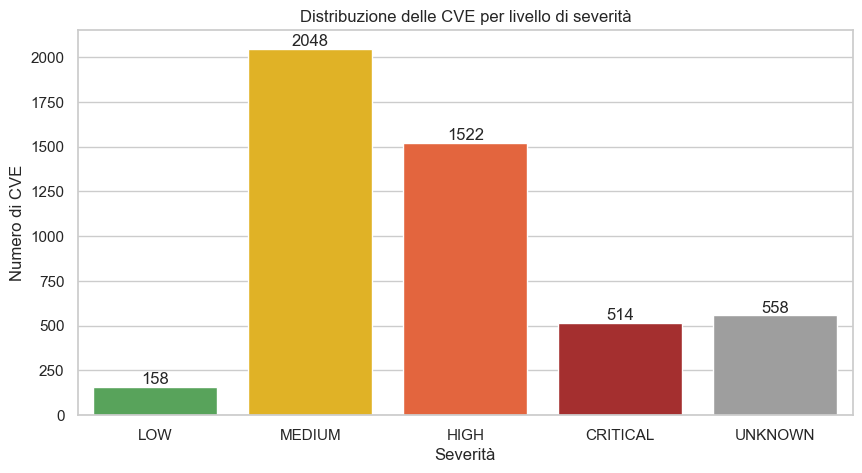

In [6]:
# Distribuzione delle severità
order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL', 'UNKNOWN']
sev_counts = df['severity'].value_counts().reindex(order).fillna(0).astype(int)
print(sev_counts)

palette = {'LOW': '#4CAF50', 'MEDIUM': '#FFC107', 'HIGH': '#FF5722', 'CRITICAL': '#B71C1C', 'UNKNOWN': '#9E9E9E'}
ax = sns.barplot(x=sev_counts.index, y=sev_counts.values, hue=sev_counts.index, palette=[palette[s] for s in sev_counts.index], legend=False)
ax.set_title('Distribuzione delle CVE per livello di severità')
ax.set_xlabel('Severità'); ax.set_ylabel('Numero di CVE')
for i, v in enumerate(sev_counts.values):
    ax.text(i, v, str(v), ha='center', va='bottom')
plt.show()

In [7]:
# Statistiche descrittive del punteggio CVSS
df['cvss_score'].describe()

count    4242.000000
mean        6.824470
std         1.722584
min         2.000000
25%         5.500000
50%         6.700000
75%         7.800000
max        10.000000
Name: cvss_score, dtype: float64

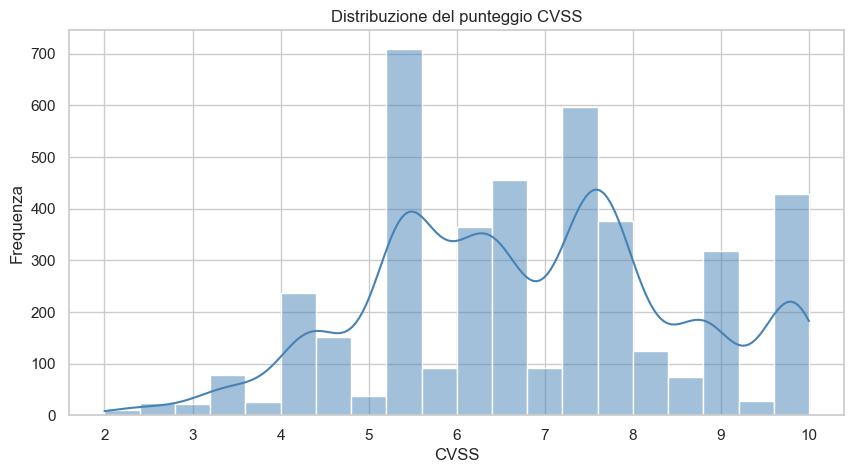

In [8]:
# Istogramma del CVSS
plt.figure(figsize=(10, 5))
sns.histplot(df['cvss_score'].dropna(), bins=20, kde=True, color='steelblue')
plt.title('Distribuzione del punteggio CVSS')
plt.xlabel('CVSS'); plt.ylabel('Frequenza')
plt.show()

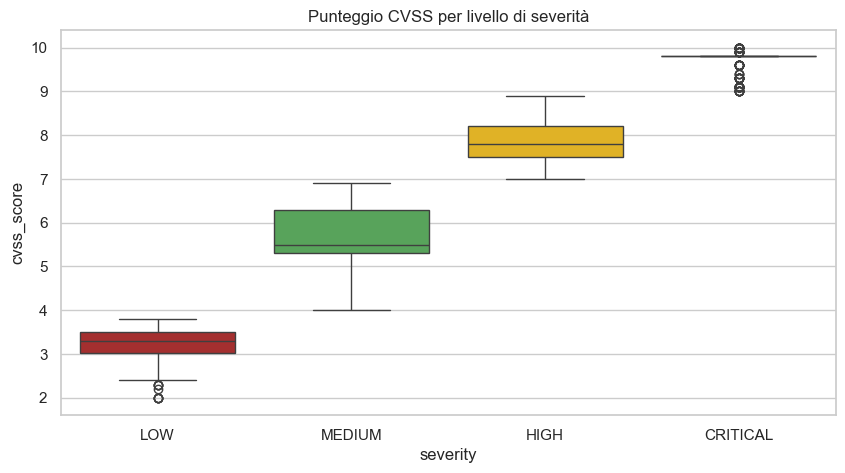

In [9]:
# Boxplot CVSS per severità
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['severity'] != 'UNKNOWN'], x='severity', y='cvss_score',
            order=['LOW', 'MEDIUM', 'HIGH', 'CRITICAL'],
            hue='severity',
            palette=['#4CAF50', '#FFC107', '#FF5722', '#B71C1C'], legend=False)
plt.title('Punteggio CVSS per livello di severità')
plt.show()

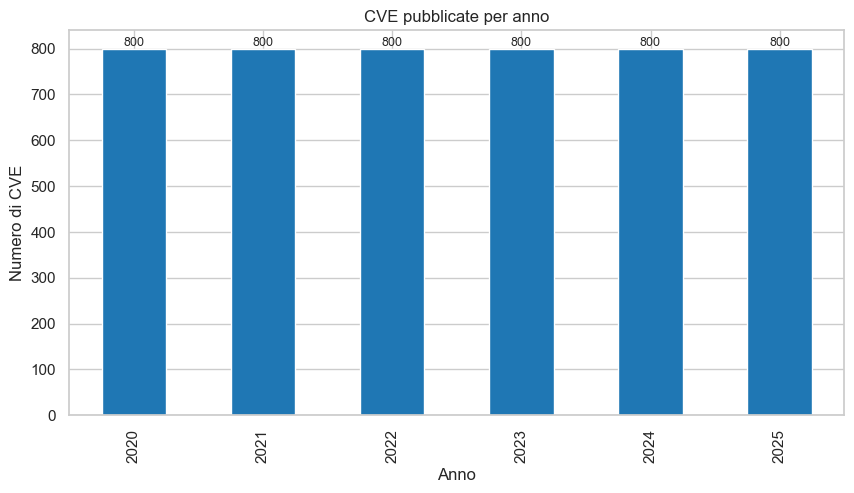

In [10]:
# CVE pubblicate per anno
per_year = df.groupby('year').size().sort_index()
ax = per_year.plot(kind='bar', color='#1f77b4')
ax.set_title('CVE pubblicate per anno')
ax.set_xlabel('Anno'); ax.set_ylabel('Numero di CVE')
for i, v in enumerate(per_year.values):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=9)
plt.show()

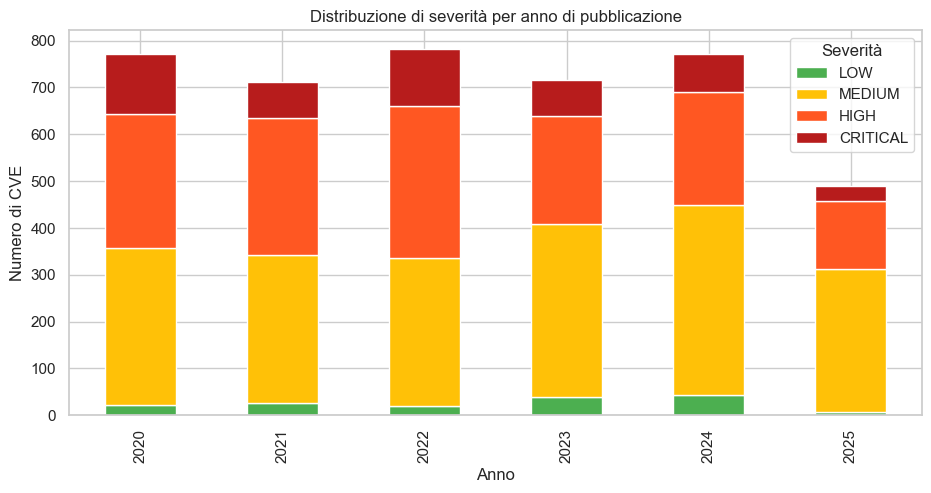

In [11]:
# Severità per anno (stacked bar)
stacked = (df[df['severity'] != 'UNKNOWN']
           .groupby(['year', 'severity']).size().unstack(fill_value=0)
           .reindex(columns=['LOW','MEDIUM','HIGH','CRITICAL']))
stacked.plot(kind='bar', stacked=True, color=['#4CAF50','#FFC107','#FF5722','#B71C1C'],
             figsize=(11,5))
plt.title('Distribuzione di severità per anno di pubblicazione')
plt.xlabel('Anno'); plt.ylabel('Numero di CVE')
plt.legend(title='Severità')
plt.show()

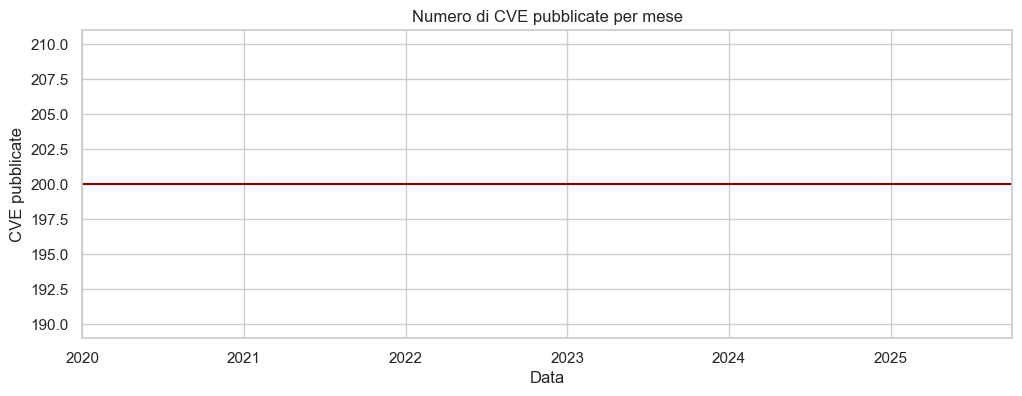

In [12]:
# Trend mensile (linea)
per_month = df.groupby(df['published'].dt.to_period('M')).size()
per_month.index = per_month.index.to_timestamp()
plt.figure(figsize=(12, 4))
per_month.plot(color='darkred')
plt.title('Numero di CVE pubblicate per mese')
plt.xlabel('Data'); plt.ylabel('CVE pubblicate')
plt.show()

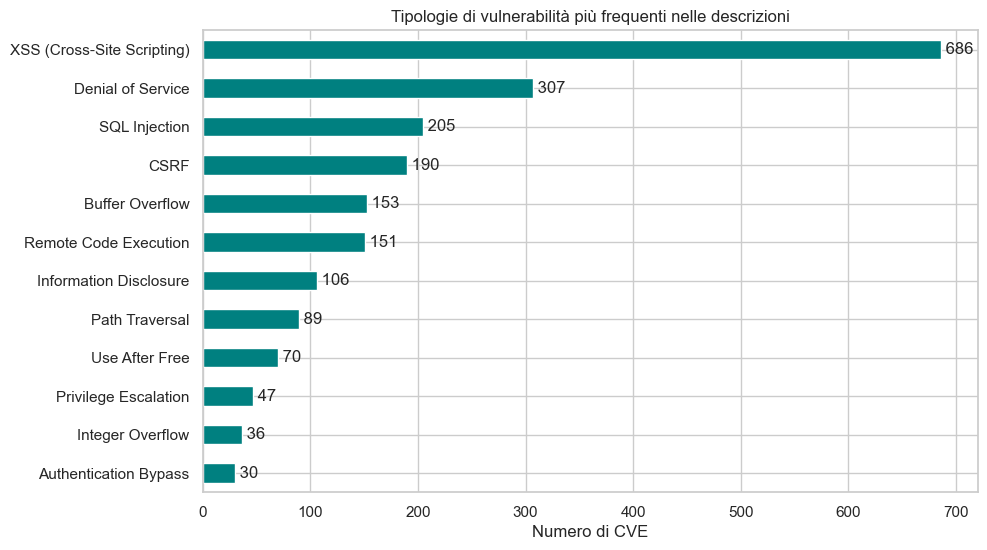

In [13]:
# Analisi testuale: tipologie di vulnerabilità più frequenti
vuln_patterns = {
    'XSS (Cross-Site Scripting)': r'\b(?:xss|cross[- ]site scripting)\b',
    'SQL Injection':              r'\bsql injection\b',
    'Buffer Overflow':            r'\bbuffer overflow\b',
    'Integer Overflow':           r'\binteger overflow\b',
    'Use After Free':             r'\buse[- ]after[- ]free\b',
    'Denial of Service':          r'\b(?:denial of service|dos)\b',
    'Remote Code Execution':      r'\b(?:remote code execution|rce|arbitrary code execution)\b',
    'Privilege Escalation':       r'\bprivilege escalation\b',
    'Information Disclosure':     r'\binformation disclosure\b',
    'Path Traversal':             r'\bpath traversal|directory traversal\b',
    'CSRF':                       r'\b(?:csrf|cross[- ]site request forgery)\b',
    'Authentication Bypass':      r'\bauthentication bypass\b',
}

desc_lower = df['description'].fillna('').str.lower()
vuln_counts = {label: int(desc_lower.str.contains(pat, regex=True).sum()) for label, pat in vuln_patterns.items()}
vuln_series = pd.Series(vuln_counts).sort_values(ascending=True)

ax = vuln_series.plot(kind='barh', color='teal', figsize=(10,6))
ax.set_title('Tipologie di vulnerabilità più frequenti nelle descrizioni')
ax.set_xlabel('Numero di CVE')
for i, v in enumerate(vuln_series.values):
    ax.text(v, i, f' {v}', va='center')
plt.show()

In [14]:
# Top 25 parole più frequenti nelle descrizioni (escluse stop word)
stop = set('''a an the and or of in on for to with from by is are was were be been being
this that these those it its as at into not but if then so can may will would could
via using used use has have had which when where what who whom an x_x  also -- via.'''.split())

tokens = re.findall(r"[a-zA-Z][a-zA-Z0-9_\-\.]{2,}", ' '.join(desc_lower.tolist()))
tokens = [t for t in tokens if t not in stop and not t.isdigit()]
common = Counter(tokens).most_common(25)
common_df = pd.DataFrame(common, columns=['parola', 'occorrenze'])
common_df

,parola,occorrenze
0,vulnerability,2065
1,allows,1198
2,issue,1164
3,attacker,869
4,before,863
5,versions,777
6,arbitrary,750
7,user,733
8,through,706
9,remote,669


In [15]:
# Top 10 CVE con punteggio CVSS più alto
top10 = df.sort_values('cvss_score', ascending=False).head(10)[
    ['cve_id','published','cvss_score','severity','description']
]
top10

,cve_id,published,cvss_score,severity,description
3698,CVE-2024-38513,2024-07-01 19:15:05.173,10.0,CRITICAL,Fiber is an Express-inspired web framework written in Go A vulnerability present in versions prior to 2.52.5 is a se...
4081,CVE-2024-56829,2025-01-02 04:15:05.557,10.0,CRITICAL,Huang Yaoshi Pharmaceutical Management Software through 16.0 allows arbitrary file upload via a .asp filename in the...
876,CVE-2020-36157,2021-01-04 18:15:13.777,10.0,CRITICAL,"An issue was discovered in the Ultimate Member plugin before 2.1.12 for WordPress, aka Unauthenticated Privilege Esc..."
2804,CVE-2023-22814,2023-07-01 00:15:09.970,10.0,CRITICAL,An authentication bypass issue via spoofing was discovered in the token-based authentication mechanism that could al...
3626,CVE-2024-38999,2024-07-01 13:15:05.280,10.0,CRITICAL,jrburke requirejs v2.3.6 was discovered to contain a prototype pollution via the function s.contexts._.configure. Th...
3313,CVE-2023-48418,2024-01-02 23:15:11.000,10.0,CRITICAL,"In checkDebuggingDisallowed of DeviceVersionFragment.java, there is a\n possible way to access adb before SUW com..."
1801,CVE-2022-24803,2022-04-01 00:15:08.950,10.0,CRITICAL,Asciidoctor-include-ext is Asciidoctor’s standard include processor reimplemented as an extension. Versions prior to...
881,CVE-2020-29491,2021-01-04 22:15:13.437,10.0,CRITICAL,Dell Wyse ThinOS 8.6 and prior versions contain an insecure default configuration vulnerability. A remote unauthenti...
3739,CVE-2023-41917,2024-07-02 08:15:03.247,10.0,CRITICAL,Inadequate input validation exposes the system to potential remote code execution (RCE) risks. Attackers can exploit...
4420,CVE-2025-41656,2025-07-01 08:15:24.443,10.0,CRITICAL,An unauthenticated remote attacker can run arbitrary commands on the affected devices with high privileges because t...


# 5. Outlier detection / preprocessing

In questa sezione si analizzano i valori anomali presenti nel dataset, con particolare attenzione alla variabile `days_to_update` (giorni tra pubblicazione e ultima modifica) e al punteggio CVSS. Si motivano le scelte di preprocessing adottate.


count    4800.000000
mean      805.658542
std       547.046213
min         0.000000
25%       349.000000
50%       776.000000
75%      1237.000000
max      2192.000000
Name: days_to_update, dtype: float64


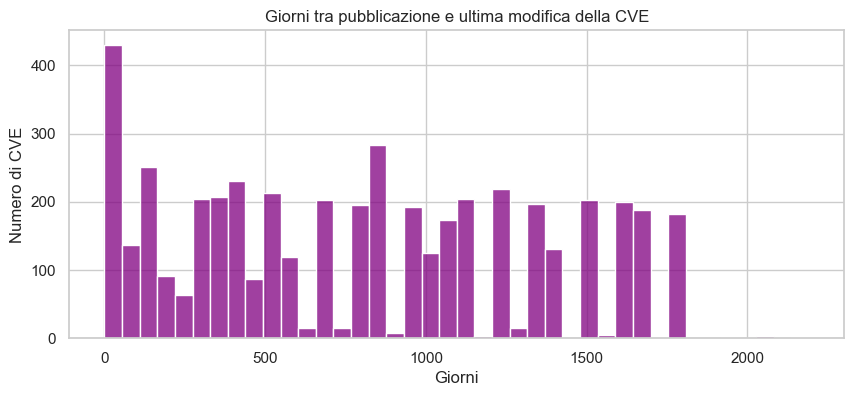

In [16]:
# Distribuzione dei giorni tra pubblicazione e ultima modifica
print(df['days_to_update'].describe())

plt.figure(figsize=(10,4))
sns.histplot(df['days_to_update'].dropna(), bins=40, color='purple')
plt.title('Giorni tra pubblicazione e ultima modifica della CVE')
plt.xlabel('Giorni'); plt.ylabel('Numero di CVE')
plt.show()

In [17]:
# Tempo medio di aggiornamento per livello di severità
df[df['severity'] != 'UNKNOWN'].groupby('severity')['days_to_update'].agg(['mean','median','count']).round(1)

,mean,median,count
severity,,,
CRITICAL,963.0,961.0,514
HIGH,914.2,961.0,1522
LOW,806.5,688.0,158
MEDIUM,791.2,775.0,2048


In [18]:
# Identificazione outlier CVSS con metodo IQR
Q1 = df['cvss_score'].quantile(0.25)
Q3 = df['cvss_score'].quantile(0.75)
IQR = Q3 - Q1
outliers_cvss = df[(df['cvss_score'] < Q1 - 1.5 * IQR) | (df['cvss_score'] > Q3 + 1.5 * IQR)]
print(f'Outlier CVSS rilevati (IQR): {len(outliers_cvss)}')
outliers_cvss[['cve_id','cvss_score','severity']].head(10)

Outlier CVSS rilevati (IQR): 5


,cve_id,cvss_score,severity
1247,CVE-2021-32729,2.0,LOW
1515,CVE-2021-39900,2.0,LOW
2613,CVE-2023-0194,2.0,LOW
2614,CVE-2023-0195,2.0,LOW
4522,CVE-2025-24335,2.0,LOW


In [19]:
# Valori anomali: days_to_update negativi (lastModified < published)
neg_days = df[df['days_to_update'] < 0]
print(f'Record con days_to_update negativo: {len(neg_days)}')

# Valori estremi: aggiornamenti dopo oltre 10 anni
extreme_days = df[df['days_to_update'] > 3650]
print(f'Record aggiornati dopo oltre 10 anni: {len(extreme_days)}')

Record con days_to_update negativo: 0
Record aggiornati dopo oltre 10 anni: 0


**Osservazioni sul preprocessing:**
- I valori `days_to_update` negativi indicano probabili errori nel dataset o record in cui `lastModified` precede `published` per motivi di backfilling; possono essere esclusi o mantenuti a seconda dell'analisi.
- Le CVE con aggiornamenti molto tardivi (>10 anni) riflettono il comportamento reale del database NVD, che revisiona costantemente le voci storiche: sono valori plausibili e non necessariamente outlier da rimuovere.
- Il campo `severity = UNKNOWN` è stato mantenuto come categoria esplicita anziché scartato, per non perdere informazioni sul volume di CVE non ancora classificate.


# 6. Implementazione di uno o più modelli

Partendo dalle feature disponibili si affronta un task di **classificazione supervisionata** per predire il livello di severità (`LOW`, `MEDIUM`, `HIGH`, `CRITICAL`) a partire dal punteggio CVSS.

**Modelli scelti:**
- **Random Forest Classifier:** robusto, interpretabile, gestisce bene soglie non lineari tra classi
- **Logistic Regression:** modello lineare usato come baseline di confronto

**Motivazione della scelta:** I due modelli consentono di confrontare un approccio non lineare (RF) con uno lineare (LR), valutando se le soglie tra i livelli di severità siano catturabili con relazioni semplici o complesse.

**Strategia di validazione:** train/test split 80/20 con stratificazione sulla variabile target `severity`.


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Dataset per il modello: escludiamo UNKNOWN e righe senza cvss_score
df_model = df[(df['severity'] != 'UNKNOWN') & df['cvss_score'].notna()].copy()

X = df_model[['cvss_score']]
y = df_model['severity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)} — Test: {len(X_test)}')

Train: 3393 — Test: 849


In [21]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

    CRITICAL       1.00      1.00      1.00       103
        HIGH       1.00      1.00      1.00       304
         LOW       1.00      1.00      1.00        32
      MEDIUM       1.00      1.00      1.00       410

    accuracy                           1.00       849
   macro avg       1.00      1.00      1.00       849
weighted avg       1.00      1.00      1.00       849



In [22]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
              precision    recall  f1-score   support

    CRITICAL       1.00      0.98      0.99       103
        HIGH       0.99      1.00      1.00       304
         LOW       1.00      0.97      0.98        32
      MEDIUM       1.00      1.00      1.00       410

    accuracy                           1.00       849
   macro avg       1.00      0.99      0.99       849
weighted avg       1.00      1.00      1.00       849



# 7. Valutazione e confronto dei risultati

Si confrontano i due modelli tramite metriche di classificazione (precision, recall, F1-score), confusion matrix e accuracy. Si interpreta criticamente la qualità dei risultati in relazione alle feature utilizzate.


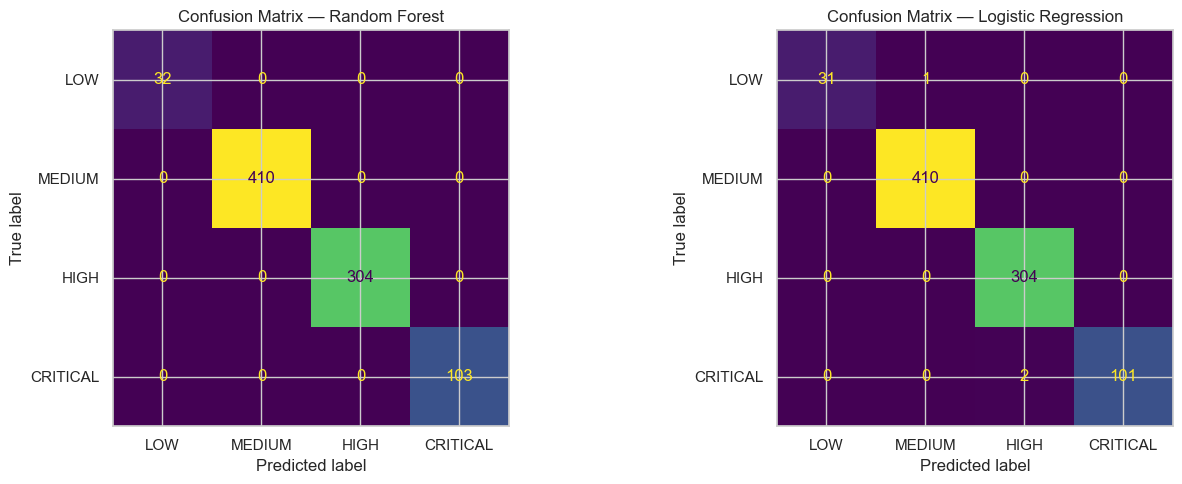

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

labels = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf, labels=labels), display_labels=labels).plot(
    ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Random Forest')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr, labels=labels), display_labels=labels).plot(
    ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix — Logistic Regression')

plt.tight_layout()
plt.show()

            Modello  Accuracy
      Random Forest  1.000000
Logistic Regression  0.996466


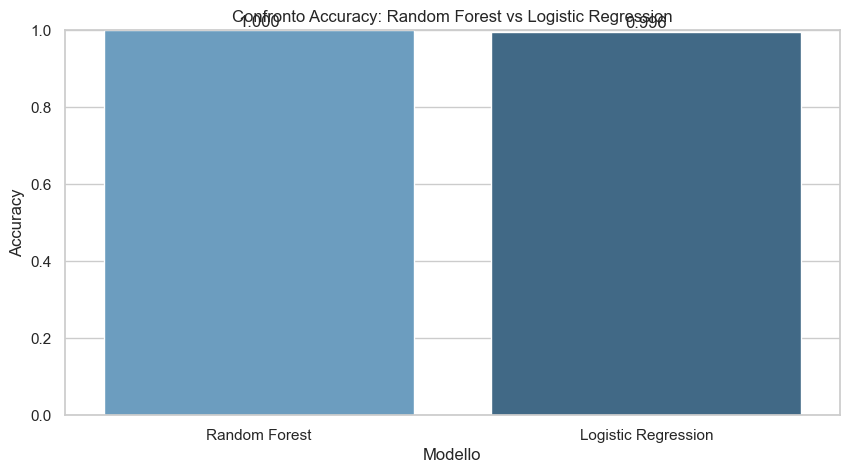

In [24]:
# Confronto accuracy dei due modelli
results = pd.DataFrame({
    'Modello': ['Random Forest', 'Logistic Regression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr)
    ]
})
print(results.to_string(index=False))

ax = sns.barplot(data=results, x='Modello', y='Accuracy', hue='Modello', palette='Blues_d', legend=False)
ax.set_ylim(0, 1)
ax.set_title('Confronto Accuracy: Random Forest vs Logistic Regression')
for i, v in enumerate(results['Accuracy']):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.show()

**Interpretazione critica:**
- Utilizzando come unica feature il `cvss_score`, i modelli ottengono accuracy elevata: il punteggio CVSS è strettamente legato per costruzione alla categorizzazione in `severity`.
- Un'accuracy molto alta può indicare correlazione quasi tautologica tra feature e target; per un'analisi più robusta si dovrebbero usare feature testuali (TF-IDF, embeddings) estratte dalla descrizione.
- Il Random Forest supera la Logistic Regression grazie alla capacità di catturare soglie non lineari tra i livelli di severità.


# 8. Conclusioni finali

**Problema affrontato:** Analisi esplorativa del database CVE per comprendere la distribuzione, i trend temporali e le tipologie delle vulnerabilità informatiche, con una componente di classificazione supervisionata della severità.

**Metodo seguito:**
- Caricamento e pulizia del dataset (parsing date, gestione valori mancanti)
- Analisi descrittiva e visualizzazioni EDA su severità, CVSS e trend temporali
- Analisi testuale con regex per classificare le tipologie di vulnerabilità
- Rilevazione di outlier su `days_to_update` e `cvss_score`
- Classificazione supervisionata con Random Forest e Logistic Regression

**Risultati principali:**
- La distribuzione è dominata da CVE **MEDIUM** e **HIGH**; le **CRITICAL** rappresentano una quota minore ma prioritaria per il patching.
- Il punteggio CVSS mediano è intorno a **6.7**, con concentrazione tra 5 e 8.
- Le tipologie più frequenti nelle descrizioni sono **buffer overflow**, **XSS**, **SQL injection** e **denial of service**.
- Il tempo tra pubblicazione e ultima modifica può essere molto lungo: molte CVE vengono riviste anche anni dopo la pubblicazione iniziale, riflettendo il continuo aggiornamento del database NVD.

**Limiti del lavoro:**
- Il modello di classificazione usa solo il CVSS score, il che introduce una correlazione quasi tautologica con la severity; future analisi dovrebbero includere feature NLP estratte dalla descrizione.
- Non è stata analizzata la dimensione vendor/prodotti colpiti per assenza di una colonna strutturata dedicata.

**Estensioni future:** clustering delle CVE per tipologia, modello NLP per classificazione automatica della severity, analisi di anomalie sui picchi mensili di pubblicazione, identificazione dei vendor più colpiti tramite parsing delle descrizioni.
